# Visualizing colocalization results

NiSpace has two integrated visualization methods that work directly on the fitted NiSpace object:

- `nsp.plot()` — colocalization results (bar charts, scatter plots, …)
- `nsp.plot_brain()` — brain surface or volume rendering of input/reference maps

This notebook walks through the customization options for both. For standalone brain plotting (independent of any NiSpace analysis), see [Notebook 8](intro08_brainplot.ipynb).

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import matplotlib.pyplot as plt

In [2]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.io import load_img
from nispace.api import NiSpace

# set up two analyses: pain map (single map) and anorexia nervosa (group comparison)
pet_maps = fetch_reference("pet", parcellation="Schaefer200",
                           collection="UniqueTracers", print_references=False)

# single map: pain
nsp_pain = NiSpace(x=pet_maps, y=load_img("neuroquery/pain.nii.gz"),
                   y_labels="Pain", parcellation="Schaefer200", seed=42, n_proc=4)
nsp_pain.fit()
nsp_pain.colocalize("spearman")
nsp_pain.permute("maps", n_perm=10000, p_tails="upper")

# group comparison: anorexia nervosa (simulated data — not for scientific use)
an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

nsp_an = NiSpace(x=pet_maps, y=an_data, parcellation="Schaefer200", seed=42, n_proc=4)
nsp_an.fit()
nsp_an.transform_y("hedges(a,b)", groups=groups)
nsp_an.colocalize("spearman")
nsp_an.permute("groups", groups=groups, n_perm=5000)

INFO | 01/06/26 11:07:36 | nispace.datasets: Loading pet maps.


INFO | 01/06/26 11:07:36 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 01/06/26 11:07:36 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 11:07:36 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


INFO | 01/06/26 11:07:36 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


...

Processing null arrays (4 proc): 100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 15407.04it/s]

Null colocalizations (spearman, 4 proc):   0%|                                                                                   | 0/5000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc):  41%|████████████████████████████▏                                        | 2040/5000 [00:00<00:00, 19389.21it/s]

Null colocalizations (spearman, 4 proc): 100%|█████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 32278.48it/s]

INFO | 01/06/26 11:08:02 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


## `nsp.plot()` — colocalization results

### Default output

The default `plot()` shows a categorical bar chart of colocalization values, colored by neurotransmitter system, with the null distribution shaded in grey.

INFO | 01/06/26 11:08:03 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_corrected < 0.05 (no correction applied)


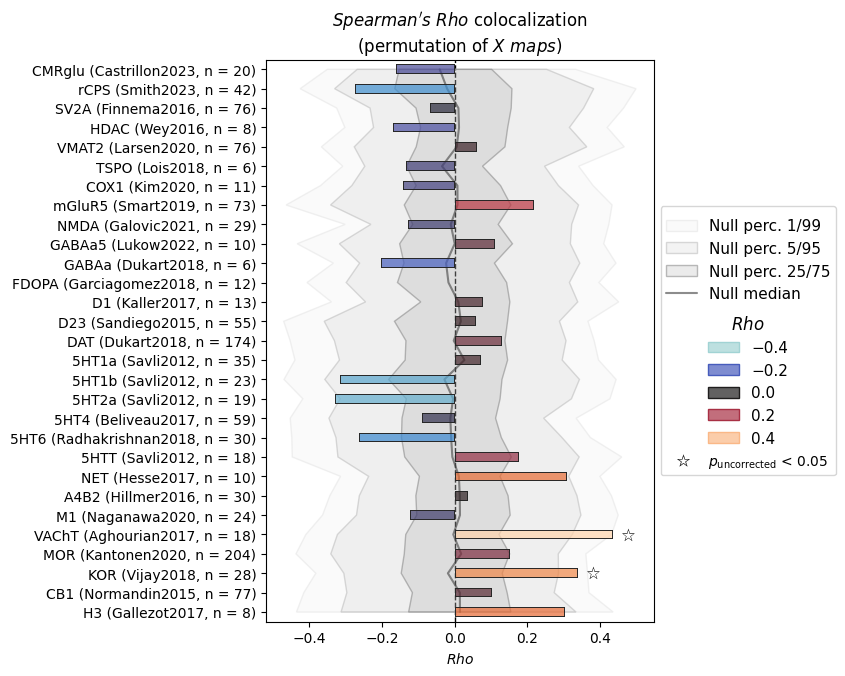

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x177ffeeb0>)

In [3]:
nsp_pain.plot()

### Values: raw correlations, z-scores, or -log10(p)

The `values` argument controls what's shown on the x-axis:
- `"coloc"` — raw colocalization values (Spearman ρ, partial r, …)
- `"z"` — null-normalized z-scores (colocalization scaled by null mean and sd)
- `"p"` — −log₁₀(p), optionally with multiple comparison correction

INFO | 01/06/26 11:08:04 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_corrected < 0.05 (no correction applied)


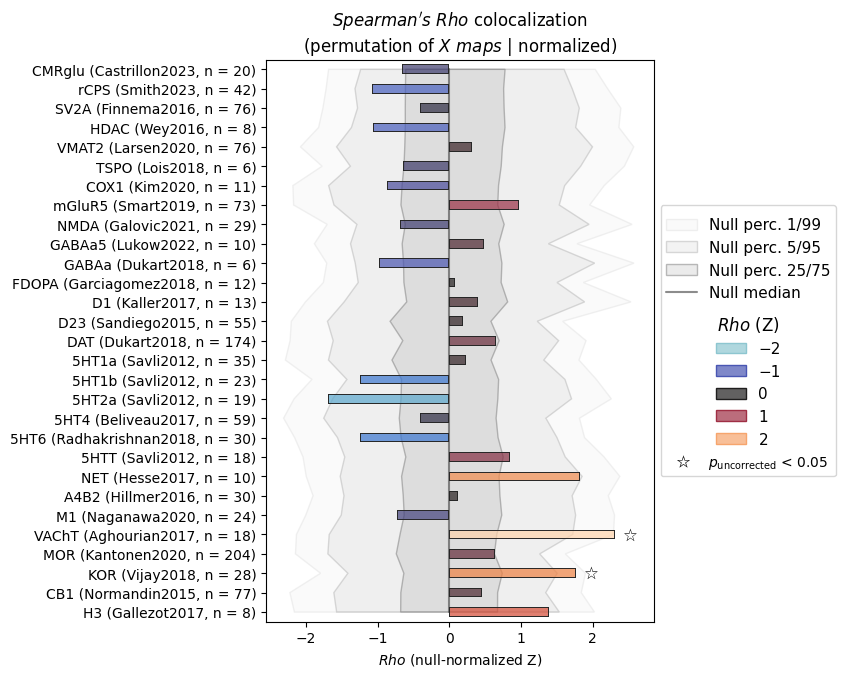

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$ | normalized)"}, xlabel='$Rho$ (null-normalized Z)'>,
 <seaborn._core.plot.Plotter at 0x148afe460>)

In [4]:
# z-normalized values (makes effect sizes more comparable across maps)
nsp_pain.normalize_colocalizations() # we need to calculate the normalized scores first
nsp_pain.plot(values="z")

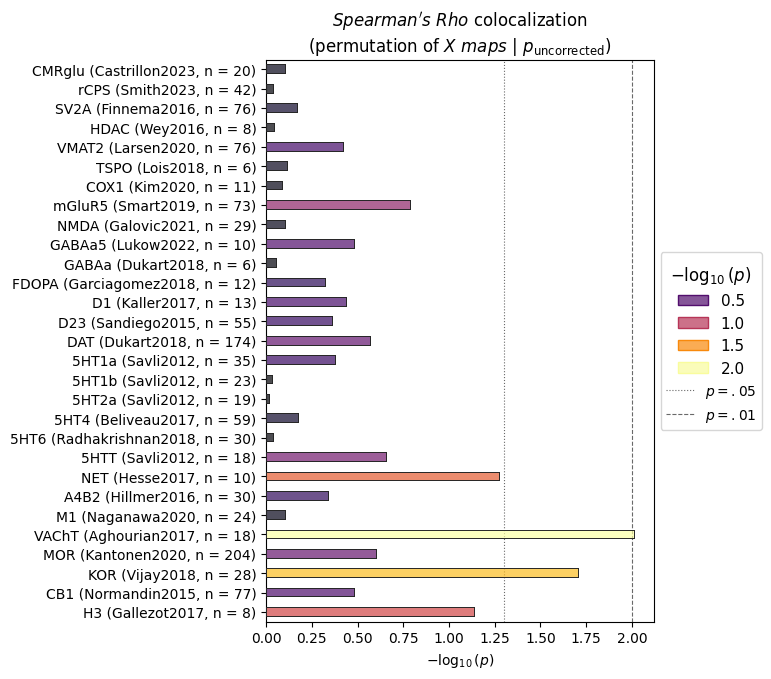

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$ | $p_{\\mathrm{uncorrected}}$)"}, xlabel='$-\\log_{10}(p)$'>,
 <seaborn._core.plot.Plotter at 0x311557490>)

In [5]:
# -log10(p), with FDR correction marked
nsp_pain.plot(values="p")

### Sorting and filtering

Use `sort_by` to reorder the bars, and `X_maps` to select a subset of reference maps.

INFO | 01/06/26 11:08:06 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_corrected < 0.05 (no correction applied)


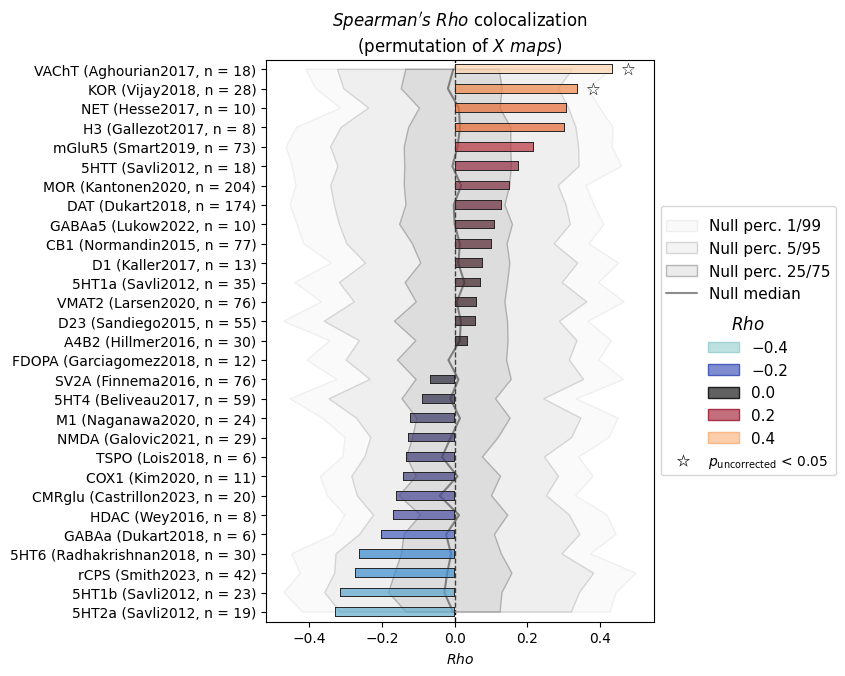

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x148cf6fa0>)

In [6]:
# sort by colocalization value
nsp_pain.plot(sort_by="coloc")

INFO | 01/06/26 11:08:07 | nispace.plotting: Significance annotation: 2/5 p_uncorrected < 0.05, 0/5 p_corrected < 0.05 (no correction applied)


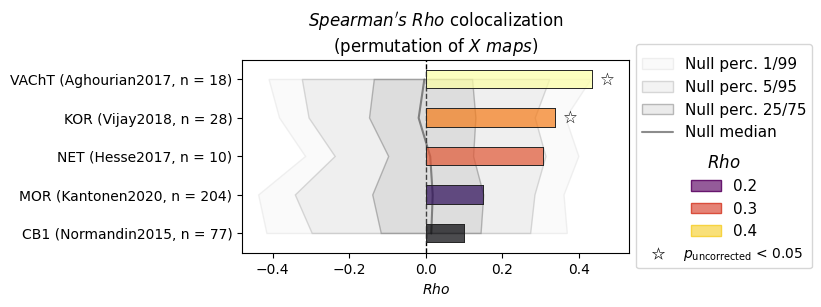

(<Figure size 500x250 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x148a06760>)

In [7]:
# show only specific systems
nsp_pain.plot(
    X_maps=["VAChT", "NET", "MOR", "KOR", "CB1"],  # match by partial name
    sort_by="coloc"
)

### P-value annotations

`annot_p` controls how significance markers are shown
- `"stats"` — show filled and empty significance stars (default; filled -> corrected; empty -> raw values)
- `"text"` - show raw p values as text
- `"both"` — show stars and raw p value as text
- `False` — no markers

INFO | 01/06/26 11:08:09 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_corrected < 0.05 (no correction applied)


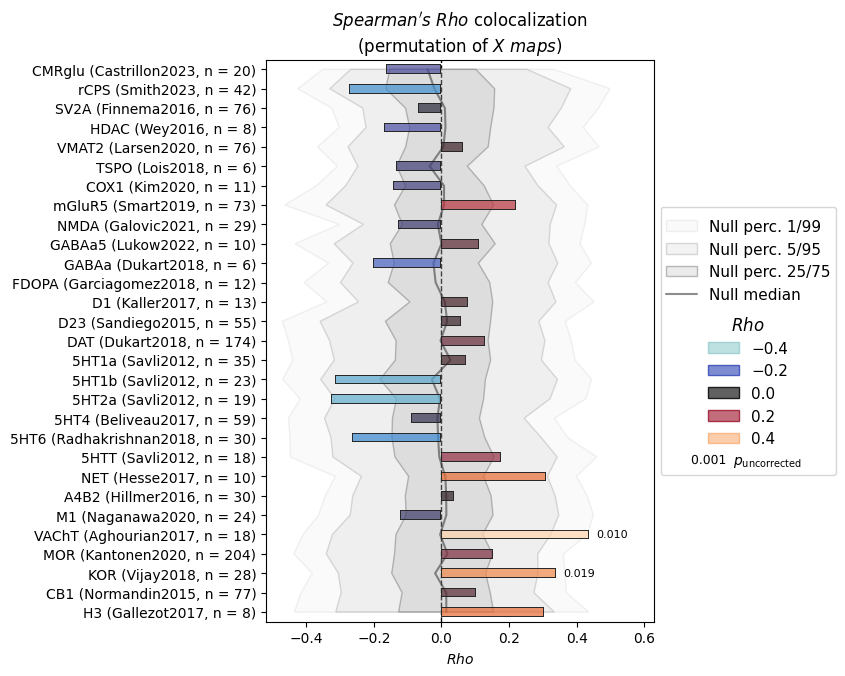

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x148caa280>)

In [8]:
nsp_pain.plot(annot_p="text")

### Passing to matplotlib

`plot()` returns `(fig, ax, plot_object)`, so you can post-process the figure with standard matplotlib calls. You can also pass `fig` and `ax` to embed the plot in an existing figure.

INFO | 01/06/26 11:08:10 | nispace.plotting: Significance annotation: 2/29 p_uncorrected < 0.05, 0/29 p_corrected < 0.05 (no correction applied)


INFO | 01/06/26 11:08:11 | nispace.plotting: Significance annotation: 9/29 p_uncorrected < 0.05, 0/29 p_corrected < 0.05 (no correction applied)


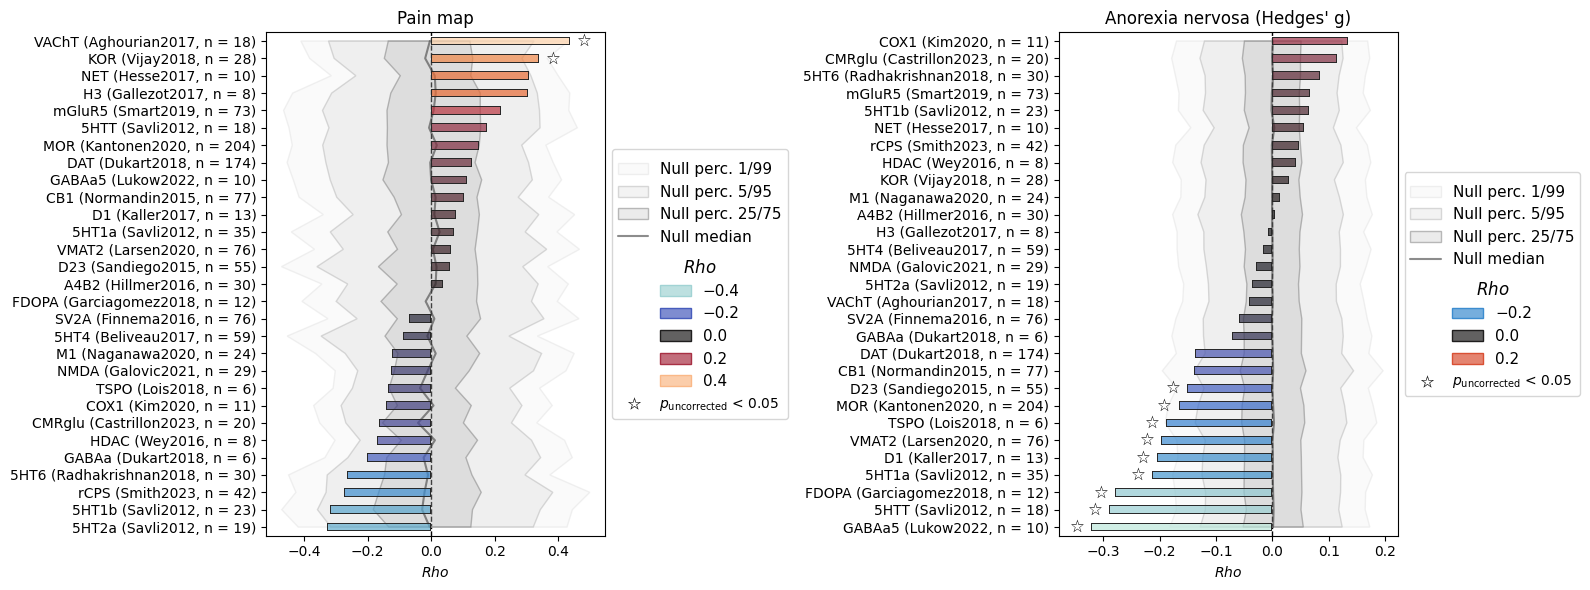

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# important: also pass the figure level, otherwise legends will behave quite unpredictably
nsp_pain.plot(ax=axes[0], fig=fig, show=False, title="Pain map", sort_by="coloc")
nsp_an.plot(ax=axes[1], fig=fig, show=False, title="Anorexia nervosa (Hedges' g)", sort_by="coloc")

plt.tight_layout()
plt.show()

## `nsp.plot_brain()` — brain surface rendering

### Basic usage

WARNING | 01/06/26 11:08:11 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 11:08:11 | nispace.plotting: brainplot: threshold='auto' → 0.005351351574063301


INFO | 01/06/26 11:08:11 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


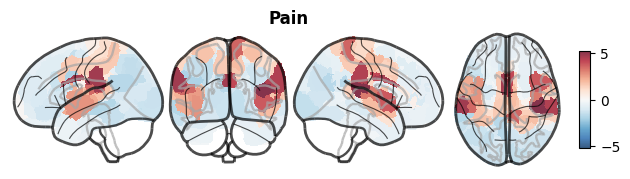

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [10]:
# plot the Y data (pain map after parcellation)
nsp_pain.plot_brain(data="Y")

WARNING | 01/06/26 11:08:14 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 11:08:14 | nispace.plotting: brainplot: threshold='auto' → 0.019260043278336525


INFO | 01/06/26 11:08:14 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


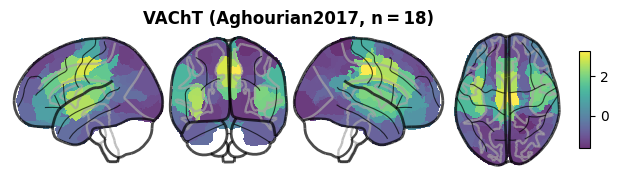

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [11]:
# plot a specific reference map
nsp_pain.plot_brain(data="X", maps="VAChT", symmetric_cmap=False)

### Rendering modes

The `kind` argument controls the rendering:
- `"surface"` — inflated cortical surface (default for cortex-only parcellations)
- `"glass"` — glass brain (transparent volumetric rendering)
- `"slice"` — anatomical slices

WARNING | 01/06/26 11:08:17 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 11:08:17 | nispace.plotting: brainplot: threshold='auto' → 0.005351351574063301


INFO | 01/06/26 11:08:17 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


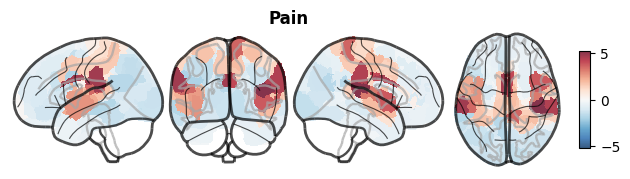

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [12]:
nsp_pain.plot_brain(data="Y", kind="glass")

WARNING | 01/06/26 11:08:21 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 11:08:21 | nispace.plotting: brainplot: threshold='auto' → 0.005351351574063301


INFO | 01/06/26 11:08:21 | nispace.plotting: brainplot: kind='slice', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


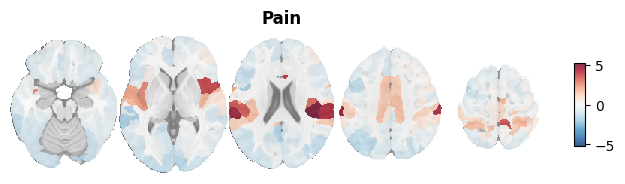

(<Figure size 700x180 with 7 Axes>, [<Axes: >])

In [13]:
nsp_pain.plot_brain(data="Y", kind="slice")

### Colormap and scale options

WARNING | 01/06/26 11:08:25 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 11:08:25 | nispace.plotting: brainplot: threshold='auto' → 0.005351351574063301


INFO | 01/06/26 11:08:25 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


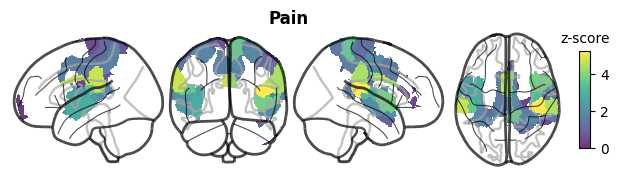

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [14]:
# custom colormap, fixed scale, colorbar label
nsp_pain.plot_brain(
    data="Y",
    cmap="viridis",
    symmetric_cmap=False,
    vmin=0,
    colorbar_label="z-score"
)

WARNING | 01/06/26 11:08:28 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 11:08:28 | nispace.plotting: brainplot: threshold='auto' → 0.00224649952724576


INFO | 01/06/26 11:08:28 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


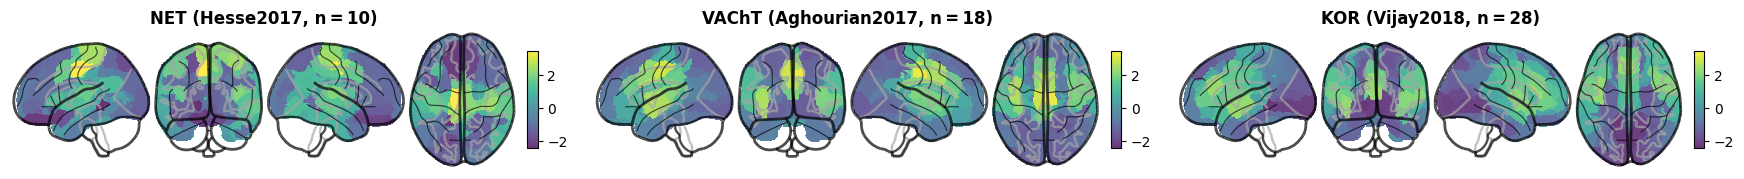

(<Figure size 2160x180 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

In [15]:
# plot multiple X maps with a shared color scale
nsp_pain.plot_brain(
    data="X",
    maps=["VAChT", "NET", "KOR"],  # only these three
    shared_colorscale=True,
    ncols=3,
    symmetric_cmap=False
)

### Surface mesh options

WARNING | 01/06/26 11:08:39 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 11:08:39 | nispace.plotting: brainplot: threshold='auto' → 0.005351351574063301


INFO | 01/06/26 11:08:39 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='pial'


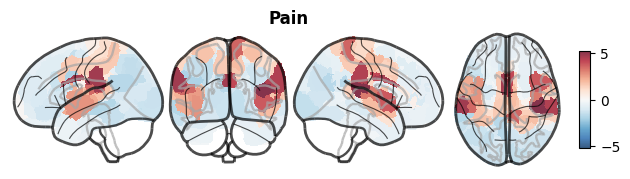

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [16]:
# pial surface instead of inflated
nsp_pain.plot_brain(data="Y", surf_mesh="pial")

## Summary

**`nsp.plot()` key arguments:**

| Argument | Options | Effect |
|----------|---------|--------|
| `values` | `"coloc"`, `"z"`, `"p"` | What to show on x-axis |
| `mc_method` | `"meff"`, `"fdr_bh"`, `"bonferroni"`, `"maxT"`, … | Multiple comparison correction |
| `sort_by` | `"coloc"`, `"p"`, `"set"` | Bar ordering |
| `annot_p` | `"right"`, `"both"`, `False` | Significance markers |
| `X_maps` | list of strings | Select subset of reference maps |
| `ax` | matplotlib Axes | Embed in existing figure |

**`nsp.plot_brain()` key arguments:**

| Argument | Options | Effect |
|----------|---------|--------|
| `data` | `"Y"`, `"X"`, DataFrame | Which maps to render |
| `maps` | string or list | Select subset of maps |
| `kind` | `"surface"`, `"glass"`, `"slice"` | Rendering mode |
| `cmap` | any matplotlib colormap | Colormap |
| `symmetric_cmap` | bool | Zero-centered color scale |
| `shared_colorscale` | bool | Same scale across all maps |

Next: [Notebook 8](intro08_brainplot.ipynb) covers the standalone `brainplot()` function — useful whenever you want to visualize brain maps outside of a NiSpace analysis.